In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import matthews_corrcoef, balanced_accuracy_score, f1_score
import pandas as pd
import numpy as np

# 1. Performance Assessment

In [2]:
df_performance = pd.read_pickle('rf_classification_activity/df_performance.pkl')

In [3]:

df_performance['MCC'] = df_performance.apply(lambda x: matthews_corrcoef(y_true=x.y_test, y_pred=x.y_pred), axis=1)
df_performance['BACC'] = df_performance.apply(lambda x: balanced_accuracy_score(y_true=x.y_test, y_pred=x.y_pred), axis=1)
df_performance['F1'] = df_performance.apply(lambda x: f1_score(y_true=x.y_test, y_pred=x.y_pred), axis=1)

<Axes: xlabel='metric', ylabel='value'>

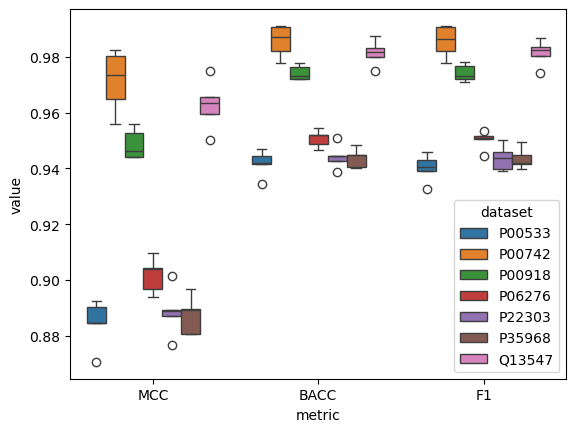

In [4]:
df_perf_molten = pd.melt(frame=df_performance,
                         id_vars=['dataset', 'split'],
                         value_vars= ['MCC', 'BACC', 'F1'],
                         value_name='value',
                         var_name='metric')
sns.boxplot(df_perf_molten,
            x='metric',
            y='value',
            hue='dataset',
)

# 2. Shapley Values

In [5]:
# get fragments of molecules as SMILES
from rdkit.Chem import MolFromSmiles, MolToSmiles, FragmentOnBRICSBonds, GetMolFrags

In [6]:
expl = pd.read_pickle('rf_classification_activity/df_explanation.pkl')
expl.dataset.unique()

array(['P00533', 'P00742', 'P00918', 'P06276', 'P22303', 'P35968',
       'Q13547'], dtype=object)

In [7]:
acc_to_name = {'P00533': 'Epidermal growth factor receptor',
               'P00742': 'Coagulation factor X',
               'P00918': 'Carbonic anhydrase 2',
               'P06276': 'Cholinesterase',
               'P22303': 'Acetylcholinesterase',
               'P35968': 'Vascular endothelial growth factor receptor 2',
               'Q13547': 'Histone deacetylase 1',}

In [8]:
ds = expl.dataset.unique()[6]
ds, acc_to_name[ds]

('Q13547', 'Histone deacetylase 1')

In [9]:
expl = expl.loc[expl.dataset == ds]

In [10]:
def remove_isotope_information_for_dummy_atoms(m):
    for at in m.GetAtoms():
        if at.GetSymbol() == '*':
            at.SetIsotope(0)
    return m

In [11]:
from rdkit.Chem import ReplaceSubstructs, RemoveAllHs, MolFromSmiles, FragmentOnBRICSBonds, GetMolFrags, MolToSmiles

def remove_dummy_atoms(m):
    dummy = MolFromSmiles('*')
    m_cleaned = ReplaceSubstructs(m, dummy, MolFromSmiles('[H]'), replaceAll=True)[0]
    return RemoveAllHs(m_cleaned, sanitize=True)

In [12]:
def get_BRICS_fragments_as_SMILES(smiles, remove_dummies=False):
    mol = MolFromSmiles(smiles)
    frag_ = FragmentOnBRICSBonds(mol)
    frags = GetMolFrags(frag_,
                        asMols=True)
    frags_cleaned = [remove_isotope_information_for_dummy_atoms(m) for m in frags]
    if remove_dummies:
        frags_cleaned = [remove_dummy_atoms(m) for m in frags_cleaned]
        
    return [MolToSmiles(m) for m in frags_cleaned]
    

In [13]:
expl['fragments_with_dummies_SMILES'] = expl.smiles.apply(get_BRICS_fragments_as_SMILES)
expl['fragments_without_dummies_SMILES'] = expl.smiles.apply(lambda x: get_BRICS_fragments_as_SMILES(x, remove_dummies=True))

[10:59:27] WARNING: not removing hydrogen atom without neighbors
[10:59:27] WARNING: not removing hydrogen atom without neighbors
[10:59:27] WARNING: not removing hydrogen atom without neighbors
[10:59:27] WARNING: not removing hydrogen atom without neighbors
[10:59:27] WARNING: not removing hydrogen atom without neighbors
[10:59:27] WARNING: not removing hydrogen atom without neighbors
[10:59:27] WARNING: not removing hydrogen atom without neighbors
[10:59:27] WARNING: not removing hydrogen atom without neighbors
[10:59:27] WARNING: not removing hydrogen atom without neighbors
[10:59:27] WARNING: not removing hydrogen atom without neighbors
[10:59:27] WARNING: not removing hydrogen atom without neighbors
[10:59:27] WARNING: not removing hydrogen atom without neighbors
[10:59:27] WARNING: not removing hydrogen atom without neighbors
[10:59:27] WARNING: not removing hydrogen atom without neighbors
[10:59:27] WARNING: not removing hydrogen atom without neighbors
[10:59:27] WARNING: not r

In [14]:
r = expl.fragExplainer_result.to_list()
r_ = [list(d.values()) for d in r]
list_of_shap = [i for j in r_ for i in j]
s = expl.fragments_with_dummies_SMILES.to_list() # here use with dummies
list_of_smiles = [smiles for l in s for smiles in l]
df_frag_single = pd.DataFrame({'smiles': list_of_smiles,
                               'value': list_of_shap})
df_analysis = df_frag_single.groupby('smiles')['value'].apply(np.array).reset_index(name='values')
df_analysis['n_fragments'] = df_analysis['values'].apply(len)
df_analysis['mean'] = df_analysis['values'].apply(np.mean)
df_analysis['std'] = df_analysis['values'].apply(np.std)

<Axes: xlabel='value', ylabel='smiles'>

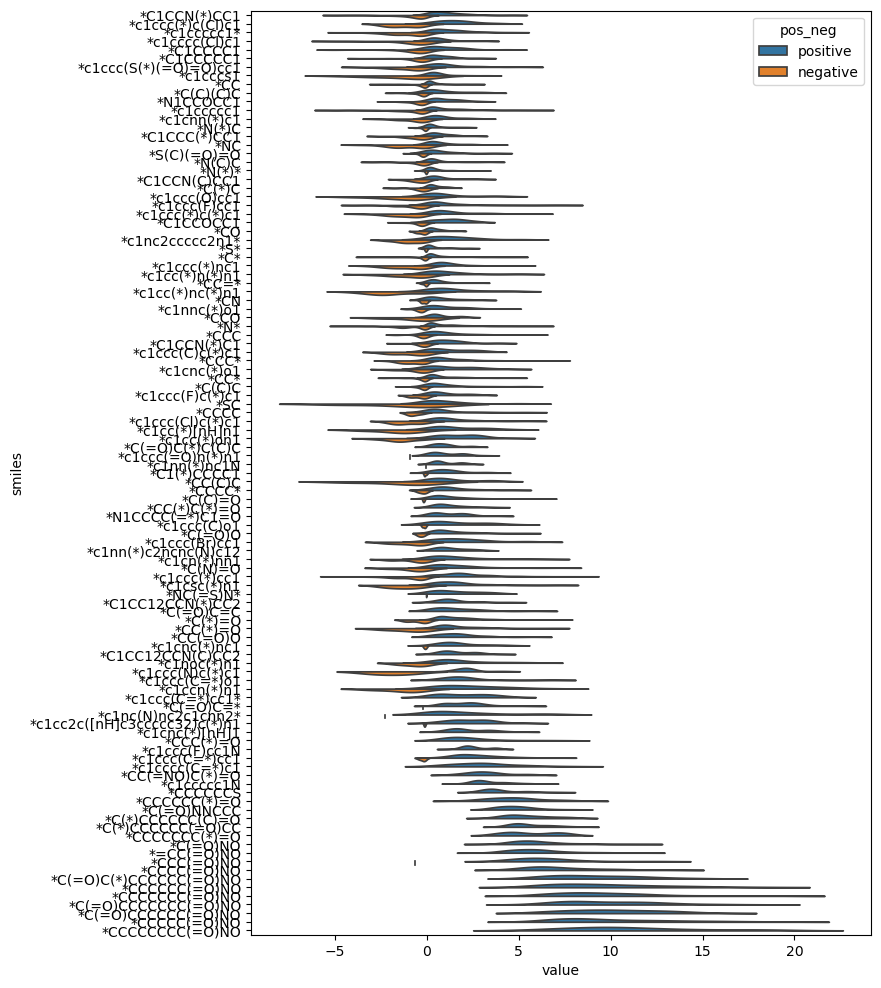

In [15]:
min_n = 25
sm_to_consider = df_analysis.loc[(df_analysis.n_fragments >= min_n) & (df_analysis['mean'] >= 0.0)].smiles.to_list() # only toxic ones

df_plot = df_frag_single.query('smiles in @sm_to_consider').copy()
df_plot['pos_neg'] = df_plot['value'].apply(lambda x: 'positive' if x >= 0 else 'negative')
mean_vals = df_analysis.loc[df_analysis.smiles.isin(sm_to_consider)]['mean'].values
sort_idx = np.argsort(mean_vals)
sm_ordered = np.array(sm_to_consider)[sort_idx]
fig, axs = plt.subplots(1, 1, figsize=(8, 12))
sns.violinplot(df_plot,
               x='value',
               y='smiles',
               order=sm_ordered,
               inner=None,
               density_norm='width',
               hue='pos_neg',
               split=True,
               ax=axs
               )

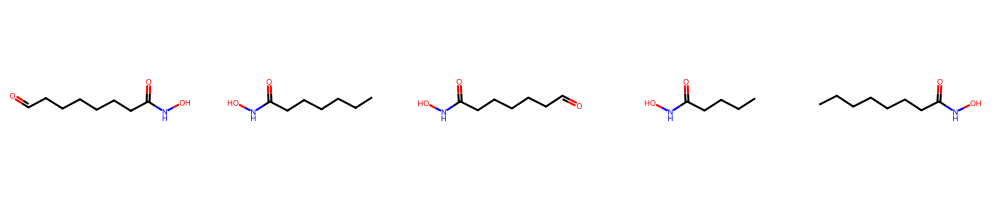

In [22]:
from rdkit.Chem.Draw import MolsMatrixToGridImage

n= 5
MolsMatrixToGridImage(molsMatrix=[[MolFromSmiles(sm) for sm in sm_ordered[-n:]]])